# Degradation stuff

## Imports

In [ ]:
import numpy as np
import pandas as pd

from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader
from redoxed.plots import GenericPlot, EfficiencyPlot
from redoxed import config
config.set_latex_mode(False)  

## Vanadium

C:\Users\es758\AppData\Local\Temp\ipykernel_8556\3699680616.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ECData_object.df['half cycle']+=110
C:\Users\es758\AppData\Local\Temp\ipykernel_8556\3699680616.py:65: UserWarning: 'timestamp' not available in MPR file metadata
  ECData_object = loader.load_data(fpath=fpath)
C:\Users\es758\AppData\Local\Temp\ipykernel_8556\3699680616.py:65: UserWarning: 'enddate' not available in MPR file metadata
  ECData_object = loader.load_data(fpath=fpath)


[90.16288058 90.18610309 90.16296684 90.10987873 90.07455067 89.98341957
 89.95363842 89.92624336 89.94072233 90.00878763 90.00117594 90.01977567
 90.03051662 90.01304579 89.98450635 89.93982064 89.97622011 89.9902076
 89.95742518 89.91941263 89.79558601 89.81083867 89.82611166 89.80468176
 89.77060138 89.66551497 89.70711259 89.677446   89.64266248 89.56898064
 89.4050684  89.3858898  89.37349749 89.33284204 89.31337808 89.14635737
 89.12241809 89.09379016 89.05808545 89.02449166 88.93239031 88.91517482
 88.86009563 88.82276178 88.79612871 88.73747477 88.73967856 88.70721433
 88.65124299 88.64342163 88.64504208 88.65395593 88.61503756 88.55141625
 88.4949122 ]
[88.19738201 88.3045449  88.79647039 89.36242827 89.70191824 89.80074872
 89.94668283 90.03506237 90.06985081]
[89.51604305 89.57165479 89.58949314 89.57925806 89.5593554  89.47416106
 89.44955635 89.49757692 89.51231796 89.47037368 89.05288996 88.98595652
 89.13100958 89.44046912 89.45912125 89.33389291 89.2935288  89.24613487


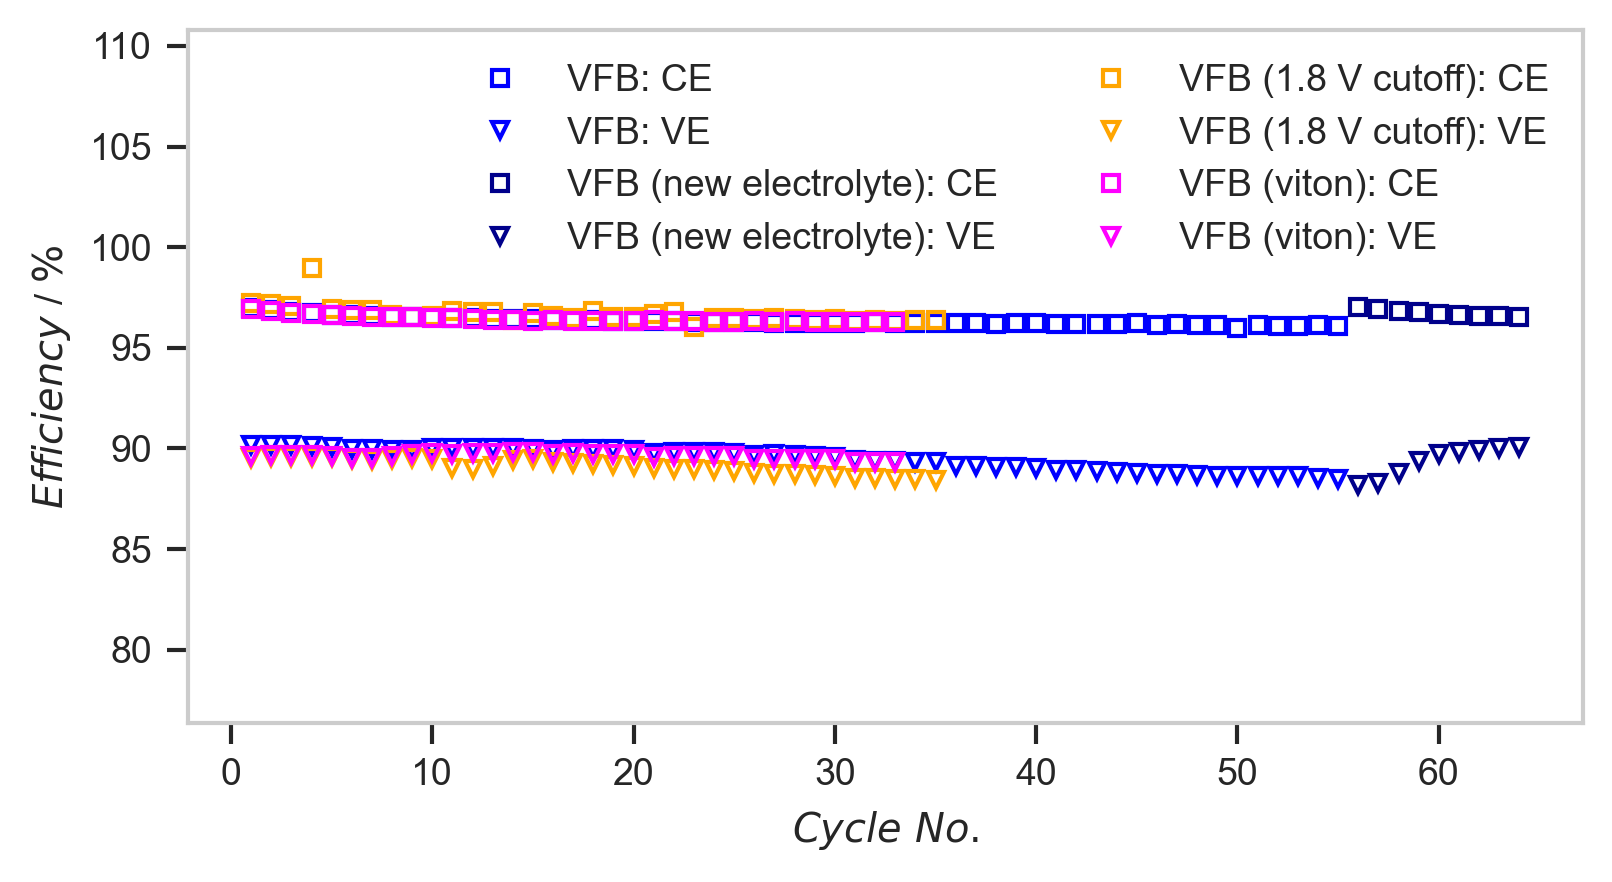

In [94]:
cycling_array = []
color_list = []

j_plot = False

EfficiencyPlot_object = EfficiencyPlot(figsize=(6, 3), dpi=300) 


fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.29 FB2_VFB\1_VFB_22rpm_06_GCPL_C04.mpr"
label="VFB"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
#print(ECData_object.df['half cycle'].unique())
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('blue')

fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.29 FB2_VFB\2_VFB_22rpm_elecrepl_06_GCPL_C04.mpr"
label="VFB (new electrolyte)"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
#print(ECData_object.df['half cycle'].unique())
# remove incomplete cycle and continue cycle count from previous
ECData_object.df = ECData_object.filter_by_col("half cycle", lambda value: value < 18)  
ECData_object.df['half cycle']+=110
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('darkblue')

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.20 FB2_VFB_NR117_1186HCB400C24h\1_FB2_10mlV_22rpm_1p8V_06_GCPL_C04.mpr"
label="VFB (1.8 V cutoff)"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
# print(ECData_object.df['half cycle'].unique())
# remove incomplete cycle
ECData_object.df = ECData_object.filter_by_col("half cycle", lambda value: value != 70)  
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('orange')

# fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.20 FB2_VFB_NR117_1186HCB400C24h\3_FB2_10mlV_22rpm_1p8V10min_06_GCPL_C04.mpr"
# label="VFB (1.8 V cutoff new electrolyte)"
# loader = LoaderFactory.get_loader(fpath)
# ECData_object = loader.load_data(fpath=fpath)
# print(ECData_object.df['half cycle'].unique())
# # remove incomplete cycle
# ECData_object.df = ECData_object.filter_by_col("half cycle", lambda value: value != 18)  
# # Continue cycle count from previous
# ECData_object.df['half cycle']+=70
# CyclingData_object = ECData_object.to_CyclingData()
# CyclingData_object.label = label
# CyclingData_object.set_area(0.0005)  # m2
# cycling_array.append(CyclingData_object)
# color_list.append('darkorange')

fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.09.10 FB2_VFB_viton\1_VFB_22rpm_06_GCPL_C04.mpr"
label="VFB (viton)"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
#print(ECData_object.df['half cycle'].unique())
# remove incomplete cycle
ECData_object.df = ECData_object.filter_by_col("half cycle", lambda value: value < 66)  
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('magenta')

for i, CyclingData_object in enumerate(cycling_array):
    EfficiencyPlot_object.add_plot(CyclingData_object, linestyle="", markersize=4, markerfacecolor='none', markeredgecolor=color_list[i], color=color_list[i], plot_CE=True, plot_VE=True, plot_EE=False)
    print(CyclingData_object.cycle_data['VE'].to_numpy())
    if j_plot == True:
        EfficiencyPlot_object.add_j(x = CyclingData_object.cycle_data['cycle_number'], j = (1e3*CyclingData_object.cycle_data['I_cell_avg_charge'])/(1e4*CyclingData_object.area), linestyle="-", marker="", color='red', label="j")

if j_plot == True:
    EfficiencyPlot_object.ax2.set_ylim(0, 100)

EfficiencyPlot_object.ax.legend(ncols=2)
#EfficiencyPlot_object.ax.set_ylim([80, 100])
#EfficiencyPlot_object.ax.set_xlim([0, None])

display(EfficiencyPlot_object.fig)

## DHPS

0     85.316473
1     84.899791
2     84.693850
3     84.490842
4     84.402141
5     84.300793
6     84.235821
7     84.087445
8     84.002506
9     84.017925
10    83.960303
11    83.908881
12    83.820177
13    83.833758
14    83.743916
15    83.728086
16    83.697846
17    83.613562
18    83.564893
19    83.576434
20    83.709857
21    83.700786
22    83.651460
23    83.680867
24    83.770568
Name: VE, dtype: float64
0     82.309749
1     82.208239
2     82.188081
3     82.069137
4     82.050002
5     81.985709
6     81.917835
7     81.806104
8     81.752183
9     81.715685
10    81.779744
11    81.659214
12    81.593847
13    81.538423
14    81.477498
15    81.610525
16    81.500187
17    81.409040
18    81.382934
19    81.350977
20    81.503936
21    81.453200
22    81.428342
23    81.348566
24    81.369388
Name: VE, dtype: float64


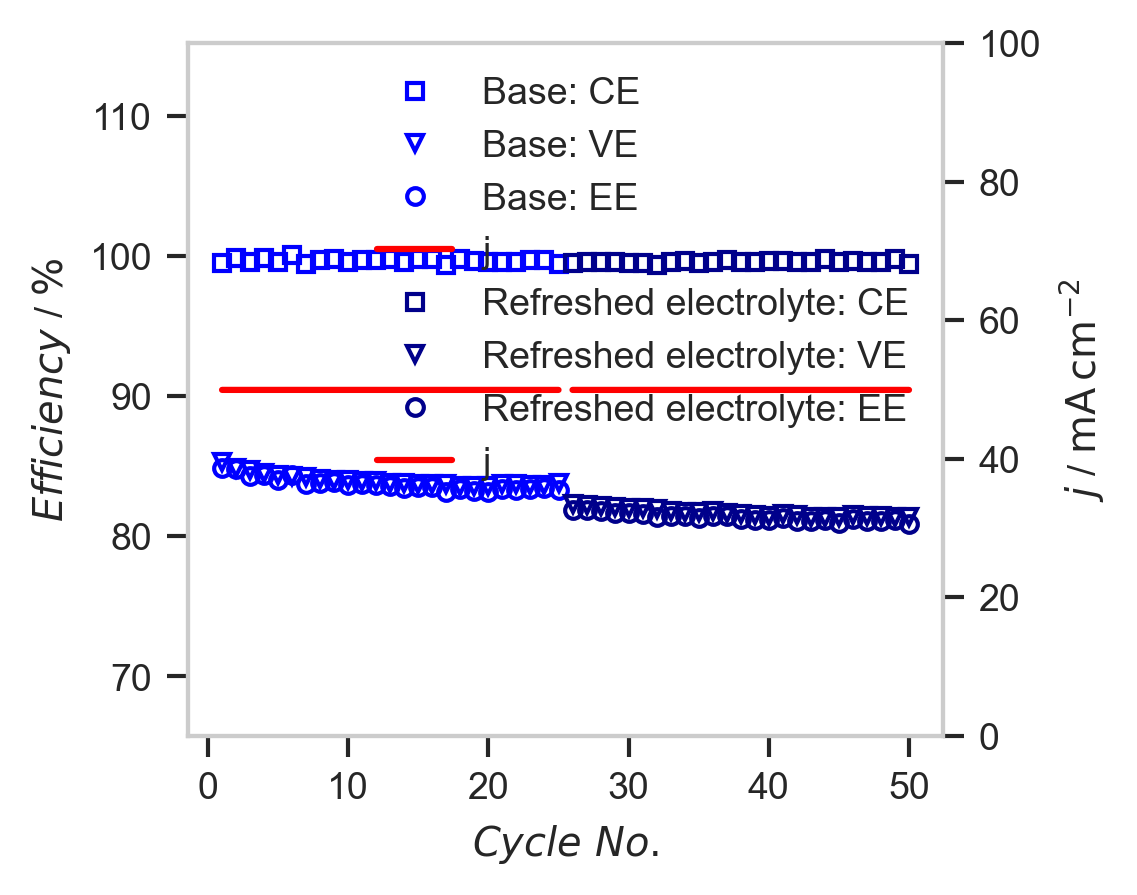

In [73]:
# KOH pristine
r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.06 FB2_DHPS_E620K_FCN_1186HCB\1_FB2_20ml20mMDHPS_40ml200mMFCN_22rpm_04_GCPL_C04.mpr"
# KOH replaced electrolyte
r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.06 FB2_DHPS_E620K_FCN_1186HCB\2_FB2_20ml20mMDHPS_40ml200mMFCN_22rpm_newelec_04_GCPL_C04.mpr"
# there is then a 0 soc wash and DMSO wash and then emptied and refilled (but under inert)

cycling_array = []
color_list = []

j_plot = True

EfficiencyPlot_object = EfficiencyPlot(figsize=(3.25, 3), dpi=300) 


fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.06 FB2_DHPS_E620K_FCN_1186HCB\1_FB2_20ml20mMDHPS_40ml200mMFCN_22rpm_04_GCPL_C04.mpr"
label="Base"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('blue')

fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.06 FB2_DHPS_E620K_FCN_1186HCB\2_FB2_20ml20mMDHPS_40ml200mMFCN_22rpm_newelec_04_GCPL_C04.mpr"
label="Refreshed electrolyte"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
ECData_object.df['half cycle']+=25*2
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('darkblue')

for i, CyclingData_object in enumerate(cycling_array):
    EfficiencyPlot_object.add_plot(CyclingData_object, linestyle="", markersize=4, markerfacecolor='none', markeredgecolor=color_list[i], color=color_list[i], plot_CE=True, plot_VE=True)
    print(CyclingData_object.cycle_data['VE'])
    if j_plot == True:
        EfficiencyPlot_object.add_j(x = CyclingData_object.cycle_data['cycle_number'], j = (1e3*CyclingData_object.cycle_data['I_cell_avg_charge'])/(1e4*CyclingData_object.area), linestyle="-", marker="", color='red', label="j")

if j_plot == True:
    EfficiencyPlot_object.ax2.set_ylim(0, 100)

EfficiencyPlot_object.ax.legend()
#EfficiencyPlot_object.ax.set_ylim([80, 100])
#EfficiencyPlot_object.ax.set_xlim([0, None])

display(EfficiencyPlot_object.fig)

C:\Users\es758\AppData\Local\Temp\ipykernel_8556\3995939960.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ECData_object.df['half cycle']+=25*2
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


0     84.997500
1     84.942355
2     84.883013
3     84.853992
4     84.770771
5     84.858597
6     84.813354
7     84.784337
8     84.735543
9     84.737205
10    84.772926
11    84.763791
12    84.718119
13    84.678475
14    84.660963
15    84.687332
16    84.663066
17    84.638409
18    84.692835
19    84.662893
20    84.856442
21    84.817066
22    84.798158
23    84.775333
24    84.806708
Name: VE, dtype: float64
0     84.902863
1     84.677537
2     85.020507
3     84.969057
4     84.924177
5     84.889888
6     84.800483
7     84.728694
8     84.751722
9     84.701171
10    84.697658
11    84.586303
12    84.603965
13    84.591400
14    84.583759
15    84.524399
16    84.465404
17    84.494454
18    84.535778
19    84.556377
20    84.654790
21    84.663181
22    84.715582
23    84.715954
24    84.771171
Name: VE, dtype: float64


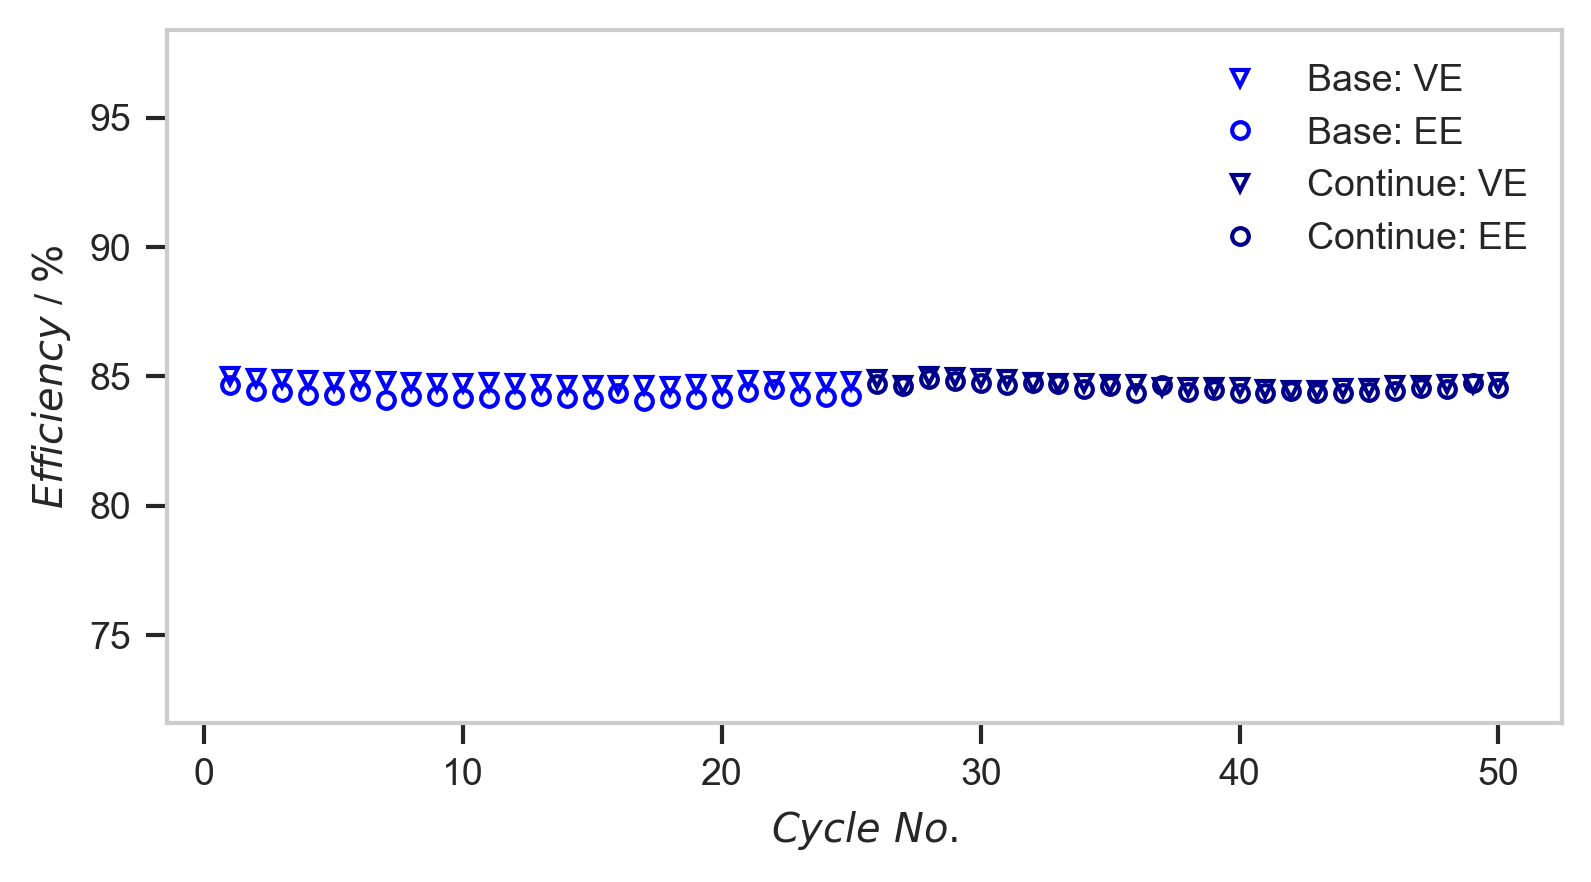

In [29]:
cycling_array = []
color_list = []

j_plot = False

EfficiencyPlot_object = EfficiencyPlot(figsize=(6, 3), dpi=300) 


fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.11 FB2_DHPS_NR212_NaOH_FCN_1186HCB\1_FB2_20ml100mMDHPS_40ml200mMFCN_22rpm_04_GCPL_C04.mpr"
label="Base"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('blue')

fpath=r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.08.11 FB2_DHPS_NR212_NaOH_FCN_1186HCB\2_FB2_20ml100mMDHPS_40ml200mMFCN_22rpm_continue_04_GCPL_C04.mpr"
label="Continue"
loader = LoaderFactory.get_loader(fpath)
ECData_object = loader.load_data(fpath=fpath)
# had to get rid of incomplete data
# print(ECData_object.columns)
# print(ECData_object.df['half cycle'].unique())
ECData_object.df = ECData_object.filter_by_col("half cycle", lambda value: value < 50)
ECData_object.df['half cycle']+=25*2
CyclingData_object = ECData_object.to_CyclingData()
CyclingData_object.label = label
CyclingData_object.set_area(0.0005)  # m2
cycling_array.append(CyclingData_object)
color_list.append('darkblue')

for i, CyclingData_object in enumerate(cycling_array):
    EfficiencyPlot_object.add_plot(CyclingData_object, linestyle="", markersize=4, markerfacecolor='none', markeredgecolor=color_list[i], color=color_list[i], plot_CE=0, plot_VE=True)
    print(CyclingData_object.cycle_data['VE'])
    if j_plot == True:
        EfficiencyPlot_object.add_j(x = CyclingData_object.cycle_data['cycle_number'], j = (1e3*CyclingData_object.cycle_data['I_cell_avg_charge'])/(1e4*CyclingData_object.area), linestyle="-", marker="", color='red', label="j")
if j_plot == True:
    EfficiencyPlot_object.ax2.set_ylim(0, 100)


EfficiencyPlot_object.ax.set_ylim([80, 90])
#EfficiencyPlot_object.ax.set_xlim([0, None])
EfficiencyPlot_object.ax.legend()
display(EfficiencyPlot_object.fig)